In [4]:
import pandas as pd
import numpy as np

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold


In [2]:
# === Load clinical data ===
clinical_df = pd.read_excel(
    r"C:\Users\Client\OneDrive - Queen Mary, University of London\PhD Shared folder\SomaScan Results\Corelation data.xlsx",
    sheet_name="COX data"
)
clinical_df.columns = (
    clinical_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace("(", "")
    .str.replace(")", "")
)


C:\Users\Client\AppData\Local\Temp\ipykernel_15736\3543445841.py:7: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  clinical_df.columns
C:\Users\Client\AppData\Local\Temp\ipykernel_15736\3543445841.py:7: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  clinical_df.columns


In [3]:
clinical_df.head()

,group_id,study_id,event_name,gender,mnd_type,site_of_onset,motor_neurone_dominant_features_from_onset,date_of_birth,sample_date,age_at_visit,...,c5,tpp2,c3,tsc22d1,plec,tf,bcl2l1,eif4a3,chgb,nefh
0,ALS F1,UCH00136,Index-Case Baseline,female,ALS,"Bulbar, UL",NaN,1935-09-18,2014-09-25,79.0,...,15.364966,11.293299,12.450258,10.493055,8.532551,18.095873,11.726218,8.915282,8.866352,8.518063
1,ALS F10,UCH00153,Index-Case Baseline,male,ALS,Bulbar,NaN,1941-10-18,2015-08-13,73.0,...,15.366326,11.280191,12.980086,10.497453,8.492654,18.134419,10.533330,8.873136,9.021813,9.932953
2,ALS F11,UCH00093,Index-Case Baseline,male,ALS,LL,NaN,1937-01-27,2013-12-19,76.0,...,15.290541,9.816824,12.278014,10.048078,9.548629,17.905072,10.316395,8.997462,9.239360,8.434628
3,ALS F12,UCH00142,Index-Case Baseline,male,ALS,LL,NaN,1946-06-11,2015-01-29,68.0,...,15.750880,10.727155,13.148445,10.454608,8.628263,18.158875,11.030667,8.862327,9.508389,8.939873
4,ALS F13,BUH00447,Index-Case Baseline,male,ALS,Bulbar,PBP - Progressive Bulbar Palsy,1937-04-18,2017-06-28,80.0,...,15.224337,10.149620,11.866545,10.509775,8.776104,17.947340,10.927111,8.867279,9.395534,8.514122


In [5]:

# -----------------------------
# 1. Define your columns
# -----------------------------
significant_proteins = [
    "tnr", "apol1", "nudt16l1", "islr2", "gstp1", "nrxn3", "apoa4", "dazap1",
    "ehd2", "c5", "tpp2", "c3", "tsc22d1", "plec", "tf", "bcl2l1", "eif4a3",
    "chgb", "nefh"
]

clinical_cols = [
    "alsfrsr", "diagnostic_delay",
    "progression_rate_at_baseline", "survival"
]

# -----------------------------
# 2. Subset your dataframe
# -----------------------------
df = clinical_df.copy()

# Drop rows missing any clinical outcome
df = df.dropna(subset=clinical_cols)

X = df[significant_proteins]

# -----------------------------
# 3. Prepare cross-validation
# -----------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# 4. Run SVR for each clinical feature
# -----------------------------
results = []

for target in clinical_cols:
    y = df[target]

    # SVR pipeline: scaling + RBF kernel
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf", C=1.0, epsilon=0.1))
    ])

    # Evaluate using R^2
    scores = cross_val_score(model, X, y, cv=cv, scoring="r2")

    results.append({
        "clinical_feature": target,
        "mean_r2": np.mean(scores),
        "std_r2": np.std(scores)
    })

results_df = pd.DataFrame(results)
print(results_df)


               clinical_feature   mean_r2    std_r2
0                       alsfrsr -0.138369  0.048800
1              diagnostic_delay -0.232846  0.141811
2  progression_rate_at_baseline  0.057418  0.135046
3                      survival -0.215829  0.144330


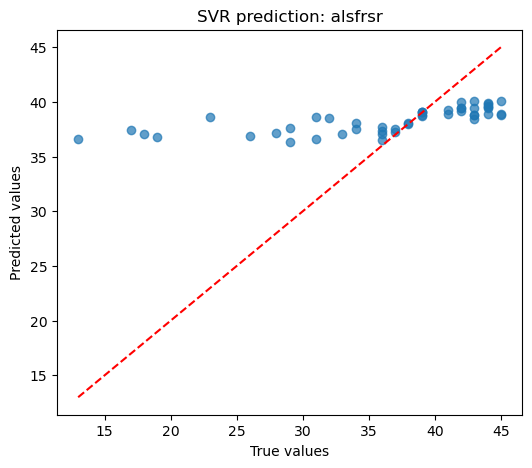

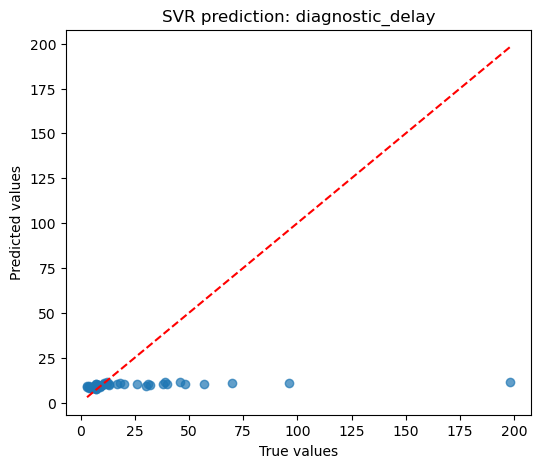

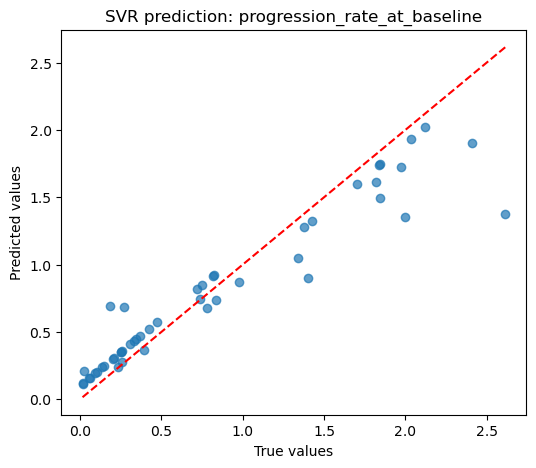

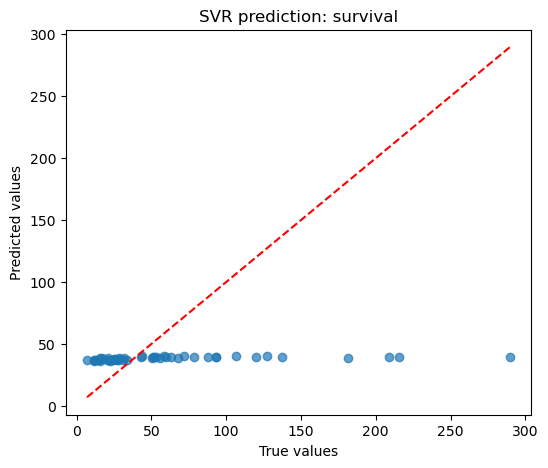

In [6]:
import matplotlib.pyplot as plt

for target in clinical_cols:
    y = df[target]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf", C=1.0, epsilon=0.1))
    ])

    model.fit(X, y)
    preds = model.predict(X)

    plt.figure(figsize=(6, 5))
    plt.scatter(y, preds, alpha=0.7)
    plt.xlabel("True values")
    plt.ylabel("Predicted values")
    plt.title(f"SVR prediction: {target}")
    plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
    plt.show()


In [7]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "svr__C": [0.1, 1, 10, 100],
    "svr__gamma": ["scale", "auto", 0.01, 0.1, 1],
    "svr__epsilon": [0.01, 0.1, 0.5, 1.0]
}

model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))
])

grid = GridSearchCV(model, param_grid, cv=5, scoring="r2")
grid.fit(X, y)

print("Best params:", grid.best_params_)
print("Best CV R²:", grid.best_score_)


Best params: {'svr__C': 10, 'svr__epsilon': 0.01, 'svr__gamma': 'scale'}
Best CV R²: -2.138493610642447


In [8]:
# === Load clinical data ===
clinical_df = pd.read_excel(
    r"C:\Users\Client\OneDrive - Queen Mary, University of London\PhD Shared folder\SomaScan Results\Corelation data.xlsx",
    sheet_name="COX data"
)
clinical_df.columns = (
    clinical_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace("(", "")
    .str.replace(")", "")
)
 -----------------------------
# 1. Define your columns
# -----------------------------
significant_proteins = [
    "tnr", "apol1", "nudt16l1", "islr2", "gstp1", "nrxn3", "apoa4", "dazap1",
    "ehd2", "c5", "tpp2", "c3", "tsc22d1", "plec", "tf", "bcl2l1", "eif4a3",
    "chgb", "nefh"
]

clinical_cols = [
    "alsfrsr", "diagnostic_delay",
    "progression_rate_at_baseline", "survival"
]

# -----------------------------
# 2. Subset your dataframe
# -----------------------------
df = clinical_df.copy()

# Drop rows missing any clinical outcome
df = df.dropna(subset=clinical_cols)

X = df[significant_proteins]

# -----------------------------
# 3. Prepare cross-validation
# -----------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# 4. Run SVR for each clinical feature
# -----------------------------
results = []

for target in clinical_cols:
    y = df[target]

    # SVR pipeline: scaling + RBF kernel
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf", C=1.0, epsilon=0.1))
    ])

    # Evaluate using R^2
    scores = cross_val_score(model, X, y, cv=cv, scoring="r2")

    results.append({
        "clinical_feature": target,
        "mean_r2": np.mean(scores),
        "std_r2": np.std(scores)
    })

results_df = pd.DataFrame(results)
print(results_df)
mport matplotlib.pyplot as plt

for target in clinical_cols:
    y = df[target]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf", C=1.0, epsilon=0.1))
    ])

    model.fit(X, y)
    preds = model.predict(X)

    plt.figure(figsize=(6, 5))
    plt.scatter(y, preds, alpha=0.7)
    plt.xlabel("True values")
    plt.ylabel("Predicted values")
    plt.title(f"SVR prediction: {target}")
    plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
    plt.show()

In [9]:

from sklearn.model_selection import KFold, cross_val_score

# -----------------------------
# 1. Define your variables
# -----------------------------
significant_proteins = [
    "tnr", "apol1", "nudt16l1", "islr2", "gstp1", "nrxn3", "apoa4", "dazap1",
    "ehd2", "c5", "tpp2", "c3", "tsc22d1", "plec", "tf", "bcl2l1", "eif4a3",
    "chgb", "nefh"
]

clinical_cols = [
    "alsfrsr", "diagnostic_delay",
    "progression_rate_at_baseline", "survival"
]

df = clinical_df.copy()
df = df.dropna(subset=clinical_cols + significant_proteins)

# -----------------------------
# 2. Choose the outcome to predict
# -----------------------------
# Example: predict ALSFRS-R using clinical covariates + 1 protein
outcome = "alsfrsr"

# -----------------------------
# 3. Prepare CV
# -----------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# 4. Loop: clinical features + 1 protein
# -----------------------------
results = []

for protein in significant_proteins:
    
    # Build feature matrix: 4 clinical covariates + 1 protein
    X = df[clinical_cols + [protein]]
    y = df[outcome]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf", C=10, epsilon=0.01, gamma="scale"))
    ])

    scores = cross_val_score(model, X, y, cv=cv, scoring="r2")

    results.append({
        "protein": protein,
        "mean_r2": np.mean(scores),
        "std_r2": np.std(scores)
    })

results_df = pd.DataFrame(results).sort_values("mean_r2", ascending=False)
print(results_df)
#check if training data and validationd data is the same


     protein   mean_r2    std_r2
3      islr2  0.891607  0.155098
7     dazap1  0.891053  0.117642
18      nefh  0.870916  0.132234
9         c5  0.866347  0.181385
15    bcl2l1  0.863516  0.185675
12   tsc22d1  0.860597  0.166747
11        c3  0.858050  0.178739
1      apol1  0.855546  0.169900
13      plec  0.853902  0.229562
16    eif4a3  0.844117  0.166921
2   nudt16l1  0.837833  0.174622
10      tpp2  0.830765  0.160108
4      gstp1  0.828651  0.122535
6      apoa4  0.827945  0.209154
0        tnr  0.827178  0.262430
14        tf  0.826669  0.201690
17      chgb  0.826448  0.187724
8       ehd2  0.815571  0.169405
5      nrxn3  0.783290  0.151043


In [10]:
all_results = []

for outcome in clinical_cols:
    for protein in significant_proteins:

        X = df[clinical_cols + [protein]]
        y = df[outcome]

        model = Pipeline([
            ("scaler", StandardScaler()),
            ("svr", SVR(kernel="rbf", C=10, epsilon=0.01, gamma="scale"))
        ])

        scores = cross_val_score(model, X, y, cv=cv, scoring="r2")

        all_results.append({
            "outcome": outcome,
            "protein": protein,
            "mean_r2": np.mean(scores),
            "std_r2": np.std(scores)
        })

all_results_df = pd.DataFrame(all_results)
print(all_results_df)


     outcome   protein   mean_r2    std_r2
0    alsfrsr       tnr  0.827178  0.262430
1    alsfrsr     apol1  0.855546  0.169900
2    alsfrsr  nudt16l1  0.837833  0.174622
3    alsfrsr     islr2  0.891607  0.155098
4    alsfrsr     gstp1  0.828651  0.122535
..       ...       ...       ...       ...
71  survival        tf  0.393345  0.166865
72  survival    bcl2l1  0.443317  0.188531
73  survival    eif4a3  0.421757  0.206172
74  survival      chgb  0.439957  0.175225
75  survival      nefh  0.439790  0.194006

[76 rows x 4 columns]


In [30]:
import pandas as pd
import numpy as np

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score

# -----------------------------
# 1. Define your variables
# -----------------------------
continuous_outcomes = [
    "alsfrsr", "diagnostic_delay",
    "progression_rate_at_baseline" 
]
top5 = ["islr2", "dazap1", "nefh", "c5", "bcl2l1"]
top8 = ["islr2", "dazap1", "nefh", "c5", "bcl2l1", "tsc22d1", "c3", "apol1"]

df = clinical_df.copy()
df = df.dropna(subset=clinical_cols + top8)

# Choose outcome to predict
outcome = "alsfrsr"

# -----------------------------
# 2. Prepare CV
# -----------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# 3. Function to evaluate model
# -----------------------------
def evaluate_model(features):
    X = df[features]
    y = df[outcome]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf", C=10, epsilon=0.01, gamma="scale"))
    ])

    scores = cross_val_score(model, X, y, cv=cv, scoring="r2")
    return np.mean(scores), np.std(scores)

# -----------------------------
# 4. Evaluate models
# -----------------------------
results = []

# Clinical only
mean_r2, std_r2 = evaluate_model(clinical_cols)
results.append({"model": "clinical_only", "mean_r2": mean_r2, "std_r2": std_r2})

# Clinical + top 5 proteins
mean_r2, std_r2 = evaluate_model(clinical_cols + top5)
results.append({"model": "clinical_plus_top5", "mean_r2": mean_r2, "std_r2": std_r2})

# Clinical + top 8 proteins
mean_r2, std_r2 = evaluate_model(clinical_cols + top8)
results.append({"model": "clinical_plus_top8", "mean_r2": mean_r2, "std_r2": std_r2})

results_df = pd.DataFrame(results)
print(results_df)


                model   mean_r2    std_r2
0       clinical_only  0.934203  0.112915
1  clinical_plus_top5  0.913280  0.076679
2  clinical_plus_top8  0.850621  0.054545


In [31]:
def evaluate_svr(X, y):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf", C=10, epsilon=0.01, gamma="scale"))
    ])
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring="r2")
    return np.mean(scores), np.std(scores)


In [38]:
top_proteins = ["islr2", "dazap1", "nefh", "c5", "bcl2l1", "tsc22d1", "c3", "apol1"]
top5 = ["islr2", "dazap1", "nefh", "c5", "bcl2l1"]
clinical_predictors = [
    "diagnostic_delay",
    "progression_rate_at_baseline",
    "age_at_visit"
]


results = []

for outcome in continuous_outcomes:
    y = clinical_df[outcome].dropna()
    df = clinical_df.loc[y.index]  # align rows

    # Clinical-only model
    X_clin = df[clinical_predictors].dropna()
    y_clin = y.loc[X_clin.index]
    mean_r2, std_r2 = evaluate_svr(X_clin, y_clin)
    results.append({"outcome": outcome, "model": "clinical_only", "mean_r2": mean_r2, "std_r2": std_r2})

    # Protein-only (top 5)
    X_p5 = df[top5].dropna()
    y_p5 = y.loc[X_p5.index]
    mean_r2, std_r2 = evaluate_svr(X_p5, y_p5)
    results.append({"outcome": outcome, "model": "protein_only_top5", "mean_r2": mean_r2, "std_r2": std_r2})

    # Clinical + top 5 proteins
    X_clin_p5 = df[clinical_predictors + top5].dropna()
    y_clin_p5 = y.loc[X_clin_p5.index]
    mean_r2, std_r2 = evaluate_svr(X_clin_p5, y_clin_p5)
    results.append({"outcome": outcome, "model": "clinical_plus_top5", "mean_r2": mean_r2, "std_r2": std_r2})

    # Clinical + top 8 proteins
    X_clin_p8 = df[clinical_predictors + top_proteins].dropna()
    y_clin_p8 = y.loc[X_clin_p8.index]
    mean_r2, std_r2 = evaluate_svr(X_clin_p8, y_clin_p8)
    results.append({"outcome": outcome, "model": "clinical_plus_top8", "mean_r2": mean_r2, "std_r2": std_r2})

results_df = pd.DataFrame(results)
print(results_df)


                         outcome               model   mean_r2    std_r2
0                        alsfrsr       clinical_only  0.288870  0.114448
1                        alsfrsr   protein_only_top5 -0.238851  0.255864
2                        alsfrsr  clinical_plus_top5  0.318257  0.270798
3                        alsfrsr  clinical_plus_top8  0.181369  0.329338
4               diagnostic_delay       clinical_only  0.576036  0.324433
5               diagnostic_delay   protein_only_top5 -0.684096  0.758744
6               diagnostic_delay  clinical_plus_top5  0.185606  0.218699
7               diagnostic_delay  clinical_plus_top8 -0.022549  0.302223
8   progression_rate_at_baseline       clinical_only  0.923211  0.076572
9   progression_rate_at_baseline   protein_only_top5 -0.213134  0.384718
10  progression_rate_at_baseline  clinical_plus_top5  0.726673  0.124452
11  progression_rate_at_baseline  clinical_plus_top8  0.714624  0.109742


In [39]:
results = []

for outcome in continuous_outcomes:
    y = clinical_df[outcome].dropna()
    df = clinical_df.loc[y.index]  # align rows

    # Clinical-only model
    X_clin = df[["diagnostic_delay", "progression_rate_at_baseline", "survival"]]
    mean_r2, std_r2 = evaluate_svr(X_clin, y)
    results.append({"outcome": outcome, "model": "clinical_only", "mean_r2": mean_r2, "std_r2": std_r2})

    # Protein-only (top 5)
    X_p5 = df[top5]
    mean_r2, std_r2 = evaluate_svr(X_p5, y)
    results.append({"outcome": outcome, "model": "protein_only_top5", "mean_r2": mean_r2, "std_r2": std_r2})

    # Clinical + top 5 proteins
    X_clin_p5 = df[["diagnostic_delay", "progression_rate_at_baseline", "survival"] + top5]
    mean_r2, std_r2 = evaluate_svr(X_clin_p5, y)
    results.append({"outcome": outcome, "model": "clinical_plus_top5", "mean_r2": mean_r2, "std_r2": std_r2})

    # Clinical + top 8 proteins
    X_clin_p8 = df[["diagnostic_delay", "progression_rate_at_baseline", "survival"] + top_proteins]
    mean_r2, std_r2 = evaluate_svr(X_clin_p8, y)
    results.append({"outcome": outcome, "model": "clinical_plus_top8", "mean_r2": mean_r2, "std_r2": std_r2})

results_df = pd.DataFrame(results)
print(results_df)


C:\Users\Client\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:839: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Client\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 136, in __call__
    score = scorer._score(
  File "C:\Users\Client\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 353, in _score
    y_pred = method_caller(estimator, "predict", X)
  File "C:\Users\Client\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 86, in _cached_call
    result, _ = _get_response_values(
  File "C:\Users\Client\anaconda3\lib\site-packages\sklearn\utils\_response.py", line 218, in _get_response_values
    y_pred, pos_label = estimator.predict(X), None
  File "C:\Users\Client\anaconda3\lib\site-packages\sklearn\pipeline.py", line 515, in predict
    return self.steps[-1][1].predict(Xt, **predict_params)
  File "C:\

                         outcome               model   mean_r2    std_r2
0                        alsfrsr       clinical_only       NaN       NaN
1                        alsfrsr   protein_only_top5 -0.238851  0.255864
2                        alsfrsr  clinical_plus_top5       NaN       NaN
3                        alsfrsr  clinical_plus_top8       NaN       NaN
4               diagnostic_delay       clinical_only       NaN       NaN
5               diagnostic_delay   protein_only_top5 -0.684096  0.758744
6               diagnostic_delay  clinical_plus_top5       NaN       NaN
7               diagnostic_delay  clinical_plus_top8       NaN       NaN
8   progression_rate_at_baseline       clinical_only       NaN       NaN
9   progression_rate_at_baseline   protein_only_top5 -0.213134  0.384718
10  progression_rate_at_baseline  clinical_plus_top5       NaN       NaN
11  progression_rate_at_baseline  clinical_plus_top8       NaN       NaN


C:\Users\Client\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:839: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\Client\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 136, in __call__
    score = scorer._score(
  File "C:\Users\Client\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 353, in _score
    y_pred = method_caller(estimator, "predict", X)
  File "C:\Users\Client\anaconda3\lib\site-packages\sklearn\metrics\_scorer.py", line 86, in _cached_call
    result, _ = _get_response_values(
  File "C:\Users\Client\anaconda3\lib\site-packages\sklearn\utils\_response.py", line 218, in _get_response_values
    y_pred, pos_label = estimator.predict(X), None
  File "C:\Users\Client\anaconda3\lib\site-packages\sklearn\pipeline.py", line 515, in predict
    return self.steps[-1][1].predict(Xt, **predict_params)
  File "C:\

In [36]:
import pandas as pd
from lifelines import CoxPHFitter

proteins = [
    "tnr", "apol1", "nudt16l1", "islr2", "gstp1", "nrxn3", "apoa4", "dazap1",
    "ehd2", "c5", "tpp2", "c3", "tsc22d1", "plec", "tf", "bcl2l1", "eif4a3",
    "chgb", "nefh"
]

time_col = "survival"
event_col = "outcome_1_rip"

df = clinical_df.copy()
df = df.dropna(subset=[time_col, event_col] + proteins)

results = []

for protein in proteins:
    sub = df[[protein, time_col, event_col]].copy()

    cph = CoxPHFitter()
    cph.fit(sub, duration_col=time_col, event_col=event_col)

    s = cph.summary.loc[protein]

    results.append({
        "protein": protein,
        "coef": s["coef"],
        "HR": s["exp(coef)"],
        "p": s["p"],
        "CI_lower": s["exp(coef) lower 95%"],
        "CI_upper": s["exp(coef) upper 95%"]
    })

results_df = pd.DataFrame(results).sort_values("p")
print(results_df)


     protein      coef         HR         p  CI_lower    CI_upper
8       ehd2  1.734183   5.664297  0.001922  1.893530   16.944156
9         c5  3.203329  24.614342  0.010289  2.130839  284.332080
14        tf  2.753512  15.697666  0.018175  1.597913  154.211578
2   nudt16l1  0.586310   1.797344  0.107181  0.880729    3.667924
4      gstp1  2.284154   9.817374  0.130662  0.507776  189.809794
18      nefh  0.516439   1.676049  0.152909  0.825533    3.402820
17      chgb  0.441316   1.554752  0.387691  0.571199    4.231894
7     dazap1  0.086224   1.090050  0.439517  0.875993    1.356413
16    eif4a3 -0.484373   0.616083  0.452149  0.174281    2.177850
11        c3  0.388686   1.475042  0.482975  0.497953    4.369382
13      plec -0.155571   0.855926  0.510698  0.538407    1.360699
12   tsc22d1 -0.262578   0.769066  0.621666  0.271053    2.182096
10      tpp2  0.144867   1.155886  0.623700  0.647999    2.061843
5      nrxn3 -0.116625   0.889919  0.775890  0.398691    1.986387
0        t

In [13]:
clinical_df.columns


Index(['group_id', 'study_id', 'event_name', 'gender', 'mnd_type',
       'site_of_onset', 'motor_neurone_dominant_features_from_onset',
       'date_of_birth', 'sample_date', 'age_at_visit',
       'date_first_weakness_noticed', 'date_of_diagnosis', 'diagnostic_delay',
       'age_at_onset', 'time_from_onset', 'time_from_diagnosis', 'alsfrsr',
       'progression_rate_at_baseline', 'rip_date', 'rip_age', 'survival',
       'outcome_1_rip', 'features_of_fronto_temporal_involvement',
       'als_diagnostic_classification', 'on_riluzole', 'tnr', 'apol1',
       'nudt16l1', 'islr2', 'gstp1', 'nrxn3', 'apoa4', 'dazap1', 'ehd2', 'c5',
       'tpp2', 'c3', 'tsc22d1', 'plec', 'tf', 'bcl2l1', 'eif4a3', 'chgb',
       'nefh'],
      dtype='object')

In [16]:


top_proteins = ["ehd2", "c5", "tf"]

df = clinical_df.copy()
df = df.dropna(subset=top_proteins + ["survival", "outcome_1_rip"])

sub = df[top_proteins + ["survival", "outcome_1_rip"]]

cph = CoxPHFitter()
cph.fit(sub, duration_col="survival", event_col="outcome_1_rip")

print(cph.summary)


               coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                  
ehd2       1.928390   6.878428  0.590555        0.770923        3.085857   
c5         2.692314  14.765801  1.108323        0.520041        4.864586   
tf         3.103293  22.271165  1.125765        0.896834        5.309751   

           exp(coef) lower 95%  exp(coef) upper 95%  cmp to         z  \
covariate                                                               
ehd2                  2.161761            21.886218     0.0  3.265385   
c5                    1.682097           129.617293     0.0  2.429179   
tf                    2.451829           202.299892     0.0  2.756609   

                  p  -log2(p)  
covariate                      
ehd2       0.001093  9.837287  
c5         0.015133  6.046152  
tf         0.005840  7.419711  


In [17]:
from lifelines.utils import concordance_index

# Protein-only model
cph = CoxPHFitter()
cph.fit(sub, duration_col="survival", event_col="outcome_1_rip")

c_index = concordance_index(
    df["survival"],
    -cph.predict_partial_hazard(sub),   # negative because higher hazard = worse survival
    df["outcome_1_rip"]
)

print("C-index:", c_index)


C-index: 0.7157446808510638


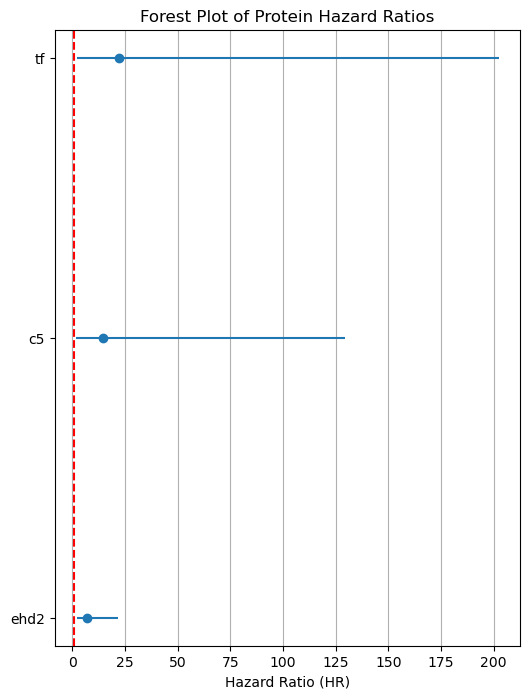

In [18]:
import matplotlib.pyplot as plt


summary = cph.summary

hr = summary["exp(coef)"]
ci_lower = summary["exp(coef) lower 95%"]
ci_upper = summary["exp(coef) upper 95%"]
proteins = summary.index

plt.figure(figsize=(6, 8))
plt.errorbar(hr, proteins, xerr=[hr - ci_lower, ci_upper - hr], fmt='o')
plt.axvline(1, color='red', linestyle='--')
plt.xlabel("Hazard Ratio (HR)")
plt.title("Forest Plot of Protein Hazard Ratios")
plt.grid(True, axis='x')
plt.show()


In [19]:
from lifelines import CoxPHFitter

df = clinical_df.copy()
df = df.dropna(subset=significant_proteins + ["survival", "outcome_1_rip"])

sub = df[significant_proteins + ["survival", "outcome_1_rip"]

cph_lasso = CoxPHFitter(penalizer=0.1, l1_ratio=1.0)  # L1 penalty = Lasso
cph_lasso.fit(sub, duration_col="survival", event_col="outcome_1_rip")

print(cph_lasso.summary)


SyntaxError: invalid syntax (1463846384.py, line 8)

In [20]:
from lifelines import CoxPHFitter

df = clinical_df.copy()
df = df.dropna(subset=significant_proteins + ["survival", "outcome_1_rip"])

sub = df[significant_proteins + ["survival", "outcome_1_rip"]]

cph_lasso = CoxPHFitter(penalizer=0.1, l1_ratio=1.0)  # L1 penalty
cph_lasso.fit(sub, duration_col="survival", event_col="outcome_1_rip")

print(cph_lasso.summary)


                   coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                      
tnr       -2.168758e-07   1.000000  0.001455       -0.002851        0.002851   
apol1      7.494331e-07   1.000001  0.001178       -0.002308        0.002310   
nudt16l1   1.522786e-01   1.164485  0.417965       -0.666917        0.971474   
islr2      1.713234e-07   1.000000  0.000600       -0.001177        0.001177   
gstp1      2.007560e-01   1.222326  1.843419       -3.412278        3.813790   
nrxn3     -1.701198e-06   0.999998  0.002795       -0.005481        0.005477   
apoa4      2.841464e-07   1.000000  0.000772       -0.001514        0.001514   
dazap1     4.637674e-02   1.047469  0.149235       -0.246119        0.338873   
ehd2       1.300615e+00   3.671554  0.582935        0.158083        2.443147   
c5         1.974129e+00   7.200349  1.082121       -0.146789        4.095048   
tpp2      -7.951998e-08   1.000000  0.00

In [22]:
top_survival_proteins = ["ehd2", "c5", "tf"]

sub = df[top_survival_proteins + ["survival", "outcome_1_rip"]]
cph = CoxPHFitter()
cph.fit(sub, duration_col="survival", event_col="outcome_1_rip")
print(cph.summary)


               coef  exp(coef)  se(coef)  coef lower 95%  coef upper 95%  \
covariate                                                                  
ehd2       1.928390   6.878428  0.590555        0.770923        3.085857   
c5         2.692314  14.765801  1.108323        0.520041        4.864586   
tf         3.103293  22.271165  1.125765        0.896834        5.309751   

           exp(coef) lower 95%  exp(coef) upper 95%  cmp to         z  \
covariate                                                               
ehd2                  2.161761            21.886218     0.0  3.265385   
c5                    1.682097           129.617293     0.0  2.429179   
tf                    2.451829           202.299892     0.0  2.756609   

                  p  -log2(p)  
covariate                      
ehd2       0.001093  9.837287  
c5         0.015133  6.046152  
tf         0.005840  7.419711  


In [23]:

from lifelines.utils import concordance_index


df = clinical_df.copy()

# Survival columns
time_col = "survival"
event_col = "outcome_1_rip"

# Protein lists
all_proteins = [
    "tnr", "apol1", "nudt16l1", "islr2", "gstp1", "nrxn3", "apoa4", "dazap1",
    "ehd2", "c5", "tpp2", "c3", "tsc22d1", "plec", "tf", "bcl2l1", "eif4a3",
    "chgb", "nefh"
]

top3 = ["ehd2", "c5", "tf"]

# Drop missing
df = df.dropna(subset=all_proteins + [time_col, event_col])

results = []

# -----------------------------
# 1. Protein-only models
# -----------------------------
for protein in all_proteins:
    sub = df[[protein, time_col, event_col]]
    cph = CoxPHFitter()
    cph.fit(sub, duration_col=time_col, event_col=event_col)

    c_index = concordance_index(
        df[time_col],
        -cph.predict_partial_hazard(sub),
        df[event_col]
    )

    results.append({
        "model": protein,
        "type": "protein_only",
        "c_index": c_index
    })

# -----------------------------
# 2. Multivariate top-3 model
# -----------------------------
sub = df[top3 + [time_col, event_col]]
cph = CoxPHFitter()
cph.fit(sub, duration_col=time_col, event_col=event_col)

c_index = concordance_index(
    df[time_col],
    -cph.predict_partial_hazard(sub),
    df[event_col]
)

results.append({
    "model": "top3_multivariate",
    "type": "multivariate",
    "c_index": c_index
})

# -----------------------------
# 3. All 19 proteins model
# -----------------------------
sub = df[all_proteins + [time_col, event_col]]
cph = CoxPHFitter()
cph.fit(sub, duration_col=time_col, event_col=event_col)

c_index = concordance_index(
    df[time_col],
    -cph.predict_partial_hazard(sub),
    df[event_col]
)

results.append({
    "model": "all_proteins",
    "type": "multivariate",
    "c_index": c_index
})

# -----------------------------
# Final results table
# -----------------------------
cindex_df = pd.DataFrame(results).sort_values("c_index", ascending=False)
print(cindex_df)


                model          type   c_index
20       all_proteins  multivariate  0.767660
19  top3_multivariate  multivariate  0.715745
8                ehd2  protein_only  0.664681
3               islr2  protein_only  0.640000
14                 tf  protein_only  0.621277
9                  c5  protein_only  0.609362
7              dazap1  protein_only  0.567660
2            nudt16l1  protein_only  0.563404
11                 c3  protein_only  0.554894
5               nrxn3  protein_only  0.553191
4               gstp1  protein_only  0.548511
13               plec  protein_only  0.538298
16             eif4a3  protein_only  0.527660
18               nefh  protein_only  0.524255
15             bcl2l1  protein_only  0.521702
10               tpp2  protein_only  0.520851
0                 tnr  protein_only  0.517447
12            tsc22d1  protein_only  0.514043
1               apol1  protein_only  0.505532
17               chgb  protein_only  0.502128
6               apoa4  protein_onl

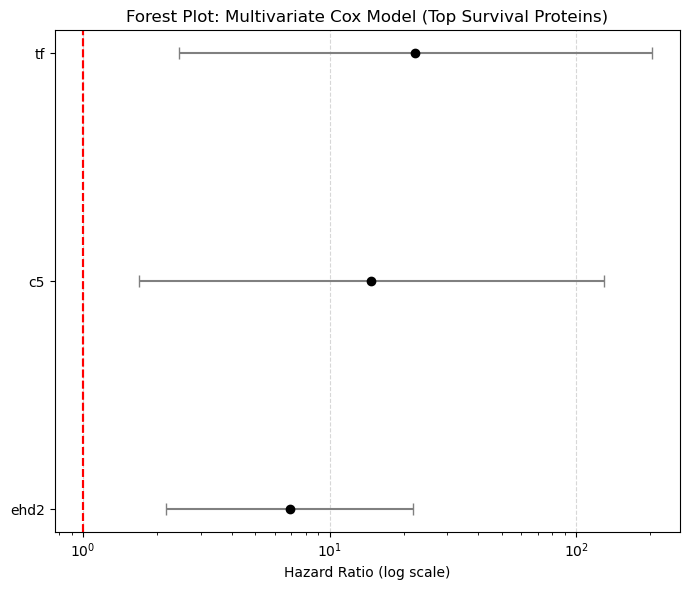

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Fit the multivariate model again
sub = df[top3 + [time_col, event_col]]
cph = CoxPHFitter()
cph.fit(sub, duration_col=time_col, event_col=event_col)

summary = cph.summary

# Extract values
hr = summary["exp(coef)"]
ci_lower = summary["exp(coef) lower 95%"]
ci_upper = summary["exp(coef) upper 95%"]
proteins = summary.index

# Plot
plt.figure(figsize=(7, 6))
plt.errorbar(
    hr,
    proteins,
    xerr=[hr - ci_lower, ci_upper - hr],
    fmt='o',
    color='black',
    ecolor='gray',
    capsize=4
)

plt.axvline(1, color='red', linestyle='--')
plt.xlabel("Hazard Ratio (HR)")
plt.title("Forest Plot: Multivariate Cox Model (Top Survival Proteins)")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xscale("log")
plt.axvline(1, color='red', linestyle='--')
plt.xlabel("Hazard Ratio (log scale)")

plt.tight_layout()
plt.show()
